# 02 — NYPD Motor Vehicle Collisions: Accident Hotspot Analysis

**Goal:** Identify where and when bicycle accidents happen in NYC. This data drives the spatial risk features in notebooks 03 and 04.

**Key question:** Are there geographic clusters of high-severity bicycle accidents near CitiBike stations?

**Data:**
- `data/raw/nypd_motor_vehicle_collisions.csv` — Crashes table (h9gi-nx95): crash-level records with location, injuries, fatalities.
- `data/raw/nypd_motor_vehicle_collisions_vehicles.csv` — Vehicles table (bm4k-52h4): per-vehicle details with standardized `VEHICLE_TYPE` (bicycle, ebike, etc.).


**Summary**
| Metric | Value |
|--------|-------|
| Total 2025 NYC crashes | 82.698 |
| Bicycle-involved crashes | 6.697|
| Cyclists injured | 5.133 |
| Peak accident hour | 16:00 |
| Highest risk borough | Manhattan/Brooklyn  |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from pathlib import Path

RAW_DIR = Path('../data/raw')
FIG_DIR = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
# --- Crashes table ---
CRASH_COLS = [
    'CRASH DATE', 'CRASH TIME', 'BOROUGH',
    'LATITUDE', 'LONGITUDE',
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
    'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
    'CONTRIBUTING FACTOR VEHICLE 1',
    'COLLISION_ID',
]

nypd = pl.read_csv(
    RAW_DIR / 'nypd_motor_vehicle_collisions.csv',
    columns=CRASH_COLS,
    infer_schema_length=10000,
)
print(f'Total NYPD crash records: {len(nypd):,}')

# --- Vehicles table ---
VEHICLE_COLS = ['COLLISION_ID', 'VEHICLE_TYPE']

vehicles = pl.read_csv(
    RAW_DIR / 'nypd_motor_vehicle_collisions_vehicles.csv',
    columns=VEHICLE_COLS,
    infer_schema_length=10000,
)
print(f'Total NYPD vehicle records: {len(vehicles):,}')

# Flag bicycle/ebike vehicles per collision (one row per collision)
bike_vehicle_ids = (
    vehicles
    .filter(
        pl.col("VEHICLE_TYPE").fill_null("").str.to_lowercase().str.contains("bicycle|bike")
    )
    .select("COLLISION_ID")
    .unique()
    .with_columns(pl.lit(True).alias("has_bike_vehicle"))
)
print(f'Collisions with a bicycle/ebike vehicle record: {len(bike_vehicle_ids):,}')

# Join bike flag onto crashes
nypd = nypd.join(bike_vehicle_ids, on="COLLISION_ID", how="left")
nypd = nypd.with_columns(pl.col("has_bike_vehicle").fill_null(False))
nypd.head(3)

Total NYPD crash records: 2,255,537
Total NYPD vehicle records: 4,524,051
Collisions with a bicycle/ebike vehicle record: 90,268


CRASH DATE,CRASH TIME,BOROUGH,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,has_bike_vehicle
str,str,str,f64,f64,i64,i64,i64,i64,str,i64,str,str,bool
"""09/11/2021""","""2:39""",null,null,null,2,0,0,0,"""Aggressive Driving/Road Rage""",4455765,"""Sedan""","""Sedan""",false
"""03/26/2022""","""11:45""",null,null,null,1,0,0,0,"""Pavement Slippery""",4513547,"""Sedan""",null,false
"""11/01/2023""","""1:29""","""BROOKLYN""",40.62179,-73.970024,1,0,0,0,"""Unspecified""",4675373,"""Moped""","""Sedan""",false


## 2. Cleaning & Filtering

In [3]:
# Parse dates and filter to 2025 (aligned with CitiBike data)
nypd = nypd.with_columns(
    pl.col("CRASH DATE").str.to_datetime("%m/%d/%Y", strict=False).alias("crash_dt")
)
nypd_2025 = nypd.filter(pl.col("crash_dt").dt.year() == 2025)
print(f'2025 records: {len(nypd_2025):,}')

# Drop rows without usable coordinates
nypd_2025 = nypd_2025.drop_nulls(subset=["LATITUDE", "LONGITUDE"])
nypd_2025 = nypd_2025.filter(
    pl.col("LATITUDE").is_between(40.4, 40.95) &
    pl.col("LONGITUDE").is_between(-74.3, -73.6)
)
print(f'After coordinate filter: {len(nypd_2025):,}')

# Flag bicycle-involved crashes (Option B: Vehicles table primary, Crashes table fallback)
bike_mask = (
    # Primary: standardized VEHICLE_TYPE from Vehicles table
    pl.col("has_bike_vehicle") |
    # Fallback: free-text VEHICLE TYPE CODE fields from Crashes table
    pl.col("VEHICLE TYPE CODE 1").fill_null("").str.to_uppercase().str.contains("BIKE|BICYCLE|CYCLIST|E-BIK") |
    pl.col("VEHICLE TYPE CODE 2").fill_null("").str.to_uppercase().str.contains("BIKE|BICYCLE|CYCLIST|E-BIK") |
    # Injury/fatality counts as additional signal
    (pl.col("NUMBER OF CYCLIST INJURED").fill_null(0) > 0) |
    (pl.col("NUMBER OF CYCLIST KILLED").fill_null(0) > 0)
)
nypd_bike = nypd_2025.filter(bike_mask)
print(f'Bicycle-involved crashes (2025): {len(nypd_bike):,}')
print(f'  Cyclists injured: {nypd_bike["NUMBER OF CYCLIST INJURED"].fill_null(0).sum():.0f}')
print(f'  Cyclists killed:  {nypd_bike["NUMBER OF CYCLIST KILLED"].fill_null(0).sum():.0f}')

2025 records: 85,541
After coordinate filter: 82,699
Bicycle-involved crashes (2025): 6,697
  Cyclists injured: 5133
  Cyclists killed:  21


## 3. Borough and Temporal Patterns

Takeaway:
* Brooklyn and Manhattan are the boroughs with highest risk
* Most injuries happen in the afternoon 16:00
* For bike crashes, insuries are very likely -> Health insurance 

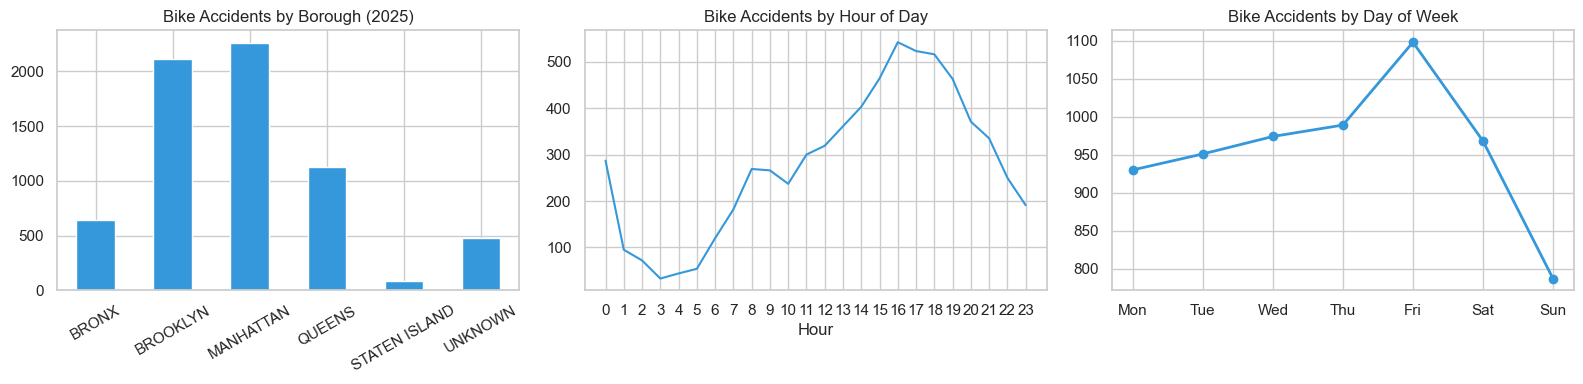

In [4]:
# Pad CRASH TIME to HH:MM — raw data uses unpadded hours ("0:34", "8:01")
# which %H cannot parse, silently producing nulls for hours 0–9.
nypd_2025 = nypd_2025.with_columns(
    pl.col("CRASH TIME").fill_null("00:00").str.pad_start(5, "0")
    .str.to_datetime("%H:%M", strict=False).dt.hour().alias("hour")
)
nypd_bike = nypd_bike.with_columns(
    pl.col("CRASH TIME").fill_null("00:00").str.pad_start(5, "0")
    .str.to_datetime("%H:%M", strict=False).dt.hour().alias("hour"),
    pl.col("crash_dt").dt.weekday().alias("weekday"),
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Borough breakdown
boro_pd = (
    nypd_bike["BOROUGH"].fill_null("UNKNOWN").value_counts()
    .sort("BOROUGH").to_pandas().set_index("BOROUGH")
)
boro_pd["count"].plot(kind='bar', ax=axes[0], color="#3498db", rot=30)
axes[0].set_title('Bike Accidents by Borough (2025)')
axes[0].set_xlabel('')

# Hour of day
hour_pd = (
    nypd_bike["hour"].drop_nulls().value_counts()
    .sort("hour").to_pandas().set_index("hour")
)
hour_pd["count"].plot(ax=axes[1], color="#3498db")
axes[1].set_title('Bike Accidents by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_xticks(range(24))

# Day of week — Polars dt.weekday() returns 1=Mon … 7=Sun
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_pd = (
    nypd_bike["weekday"].drop_nulls().value_counts()
    .sort("weekday").to_pandas().set_index("weekday")
)
dow_pd.index = [day_labels[i - 1] for i in dow_pd.index]
dow_pd["count"].plot(ax=axes[2], color="#3498db", marker='o', linewidth=2, markersize=6)
axes[2].set_title('Bike Accidents by Day of Week')
axes[2].set_xlabel('')
axes[2].set_xticks(range(len(dow_pd)))
axes[2].set_xticklabels(dow_pd.index)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_nypd_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Accident Hotspot Map

This heatmap will be layered under the station risk map in notebook 03.

In [5]:
m = folium.Map(location=[40.730, -73.990], zoom_start=12, tiles='CartoDB dark_matter')

heat_data = (
    nypd_bike.drop_nulls(subset=["LATITUDE", "LONGITUDE"])
    .select(["LATITUDE", "LONGITUDE"])
    .to_numpy()
    .tolist()
)
HeatMap(heat_data, radius=10, blur=15, max_zoom=13, name='Bike Accident Heatmap').add_to(m)

folium.LayerControl().add_to(m)
m.save(str(FIG_DIR / '02_bike_accident_heatmap.html'))
print('Map saved to outputs/figures/02_bike_accident_heatmap.html')
m

Map saved to outputs/figures/02_bike_accident_heatmap.html


## 5. Save Processed Accident Data

Notebook 03 loads this directly.

In [6]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)

nypd_2025.write_parquet('../data/processed/nypd_2025.parquet')
nypd_bike.write_parquet('../data/processed/nypd_bike_2025.parquet')
print(f'Saved {len(nypd_2025):,} total 2025 crashes and {len(nypd_bike):,} bike crashes.')

Saved 82,699 total 2025 crashes and 6,697 bike crashes.


## 6. Next
`03_spatial_analysis.ipynb` — join accident hotspots to CitiBike stations to produce a station-level risk score.